# 01 Document Ingestion and Retrieval

## Project context

This notebook builds Phase 0 of the AI Financial Research Agent. The goal is to ingest local finance documents, split them into searchable chunks, retrieve relevant evidence for research questions, and keep outputs traceable to source text.

Phase 0 uses local synthetic sample documents only. No paid APIs, OpenAI API calls, embeddings, or memo generation are used.

## Ingestion objective

- Load local `.txt` sample finance documents.
- Save document-level metadata.
- Clean and chunk text.
- Build a TF-IDF retrieval index.
- Run sample finance research queries.
- Save retrieval results and evidence tables for Phase 1.

## Sample document description

The sample documents are synthetic portfolio examples. Themes include fintech lending growth, credit risk, inflation and interest-rate risk, digital payments, bank profitability, and market volatility.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.config import (
    SAMPLE_DOCS_DIR,
    PROCESSED_DATA_DIR,
    CHUNKS_DIR,
    RETRIEVAL_DIR,
    EVIDENCE_DIR,
    FIGURES_DIR,
)
from src.ingestion import load_document_corpus, save_corpus_metadata
from src.chunking import build_chunk_table, save_chunks, clean_text
from src.retrieval import (
    build_tfidf_index,
    search_chunks,
    build_evidence_table,
    save_retrieval_results,
)
from src.visualization import (
    plot_chunks_by_document,
    plot_top_terms_overall,
    plot_retrieval_score_distribution,
)

for directory in [PROCESSED_DATA_DIR, CHUNKS_DIR, RETRIEVAL_DIR, EVIDENCE_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

## Load sample documents

In [2]:
corpus = load_document_corpus(SAMPLE_DOCS_DIR)
len(corpus), [doc["title"] for doc in corpus]

(6,
 ['Sample Note on Bank Profitability and Funding Cost',
  'Sample Note on Credit Risk and Borrower Behavior',
  'Sample Note on Digital Payments Adoption',
  'Sample Note on Fintech Lending Growth',
  'Sample Note on Inflation and Interest-Rate Risk',
  'Sample Note on Market Volatility and Portfolio Risk'])

## Corpus metadata

In [3]:
metadata = save_corpus_metadata(corpus, PROCESSED_DATA_DIR / "corpus_metadata.csv")
metadata

,document_id,file_name,title,path,character_count,word_count
0,bank_profitability_funding_cost,bank_profitability_funding_cost.txt,Sample Note on Bank Profitability and Funding ...,/Users/rovs/Documents/New project 2/projects/a...,988,143
1,credit_risk_borrower_behavior,credit_risk_borrower_behavior.txt,Sample Note on Credit Risk and Borrower Behavior,/Users/rovs/Documents/New project 2/projects/a...,1067,147
2,digital_payments_adoption,digital_payments_adoption.txt,Sample Note on Digital Payments Adoption,/Users/rovs/Documents/New project 2/projects/a...,965,123
3,fintech_lending_growth,fintech_lending_growth.txt,Sample Note on Fintech Lending Growth,/Users/rovs/Documents/New project 2/projects/a...,1120,146
4,inflation_interest_rate_risk,inflation_interest_rate_risk.txt,Sample Note on Inflation and Interest-Rate Risk,/Users/rovs/Documents/New project 2/projects/a...,978,136
5,market_volatility_portfolio_risk,market_volatility_portfolio_risk.txt,Sample Note on Market Volatility and Portfolio...,/Users/rovs/Documents/New project 2/projects/a...,960,128


## Text cleaning

In [4]:
cleaned_preview = clean_text(corpus[0]["text"])
cleaned_preview[:500]

'Title: Sample Note on Bank Profitability and Funding Cost Document type: Synthetic portfolio example This sample document was created for a portfolio prototype. It is not a real bank report. Bank profitability depends on net interest margin, fee income, credit costs, operating efficiency, and balance sheet mix. When policy rates rise, asset yields may increase, but deposit costs and wholesale funding costs can also rise. The net impact depends on repricing speed and customer behavior. Funding co'

## Chunking

In [5]:
chunks = build_chunk_table(corpus)
save_chunks(chunks, CHUNKS_DIR / "document_chunks.csv")
chunks[["chunk_id", "title", "chunk_index", "word_count"]].head(), chunks.shape

(                                     chunk_id  \
 0  bank_profitability_funding_cost__chunk_001   
 1  bank_profitability_funding_cost__chunk_002   
 2    credit_risk_borrower_behavior__chunk_001   
 3    credit_risk_borrower_behavior__chunk_002   
 4        digital_payments_adoption__chunk_001   
 
                                                title  chunk_index  word_count  
 0  Sample Note on Bank Profitability and Funding ...            1          92  
 1  Sample Note on Bank Profitability and Funding ...            2          67  
 2   Sample Note on Credit Risk and Borrower Behavior            1          82  
 3   Sample Note on Credit Risk and Borrower Behavior            2          77  
 4           Sample Note on Digital Payments Adoption            1          80  ,
 (13, 8))

## TF-IDF index creation

In [6]:
vectorizer, matrix = build_tfidf_index(chunks)
matrix.shape

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.4.1)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/rovs/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_inst

AttributeError: _ARRAY_API not found

(13, 377)

## Sample retrieval queries

In [7]:
queries = [
    "What are the main credit risk concerns?",
    "How does inflation affect financial institutions?",
    "What risks affect fintech lending growth?",
    "What does the document set say about digital payments?",
    "What market risks affect portfolio performance?",
]

retrieval_frames = [
    search_chunks(query, vectorizer, matrix, chunks, top_k=5)
    for query in queries
]
retrieval_results = pd.concat(retrieval_frames, ignore_index=True)
save_retrieval_results(retrieval_results, RETRIEVAL_DIR / "sample_retrieval_results.csv")
retrieval_results[["query", "rank", "retrieval_score", "title", "chunk_id"]].head(10)

,query,rank,retrieval_score,title,chunk_id
0,What are the main credit risk concerns?,1,0.162966,Sample Note on Credit Risk and Borrower Behavior,credit_risk_borrower_behavior__chunk_002
1,What are the main credit risk concerns?,2,0.136850,Sample Note on Credit Risk and Borrower Behavior,credit_risk_borrower_behavior__chunk_001
2,What are the main credit risk concerns?,3,0.130440,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_002
3,What are the main credit risk concerns?,4,0.107534,Sample Note on Digital Payments Adoption,digital_payments_adoption__chunk_002
4,What are the main credit risk concerns?,5,0.097510,Sample Note on Market Volatility and Portfolio...,market_volatility_portfolio_risk__chunk_002
5,How does inflation affect financial institutions?,1,0.357177,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_001
6,How does inflation affect financial institutions?,2,0.193546,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_002
7,How does inflation affect financial institutions?,3,0.000000,Sample Note on Market Volatility and Portfolio...,market_volatility_portfolio_risk__chunk_002
8,How does inflation affect financial institutions?,4,0.000000,Sample Note on Market Volatility and Portfolio...,market_volatility_portfolio_risk__chunk_001
9,How does inflation affect financial institutions?,5,0.000000,Sample Note on Fintech Lending Growth,fintech_lending_growth__chunk_003


## Evidence table

In [8]:
evidence_table = build_evidence_table(retrieval_results)
evidence_table.to_csv(EVIDENCE_DIR / "evidence_table.csv", index=False)
evidence_table.head(10)

,query,rank,retrieval_score,document_id,title,chunk_id,evidence_snippet
0,What are the main credit risk concerns?,1,0.162966,credit_risk_borrower_behavior,Sample Note on Credit Risk and Borrower Behavior,credit_risk_borrower_behavior__chunk_002,obability of default. Lenders should monitor d...
1,What are the main credit risk concerns?,2,0.136850,credit_risk_borrower_behavior,Sample Note on Credit Risk and Borrower Behavior,credit_risk_borrower_behavior__chunk_001,Title: Sample Note on Credit Risk and Borrower...
2,What are the main credit risk concerns?,3,0.130440,inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_002,"ts bond portfolios. When yields rise, fixed-ra..."
3,What are the main credit risk concerns?,4,0.107534,digital_payments_adoption,Sample Note on Digital Payments Adoption,digital_payments_adoption__chunk_002,"chant inactivity, poor dispute handling, and w..."
4,What are the main credit risk concerns?,5,0.097510,market_volatility_portfolio_risk,Sample Note on Market Volatility and Portfolio...,market_volatility_portfolio_risk__chunk_002,"crease. Risk teams monitor volatility, concent..."
5,How does inflation affect financial institutions?,1,0.357177,inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_001,Title: Sample Note on Inflation and Interest-R...
6,How does inflation affect financial institutions?,2,0.193546,inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_002,"ts bond portfolios. When yields rise, fixed-ra..."
7,How does inflation affect financial institutions?,3,0.000000,market_volatility_portfolio_risk,Sample Note on Market Volatility and Portfolio...,market_volatility_portfolio_risk__chunk_002,"crease. Risk teams monitor volatility, concent..."
8,How does inflation affect financial institutions?,4,0.000000,market_volatility_portfolio_risk,Sample Note on Market Volatility and Portfolio...,market_volatility_portfolio_risk__chunk_001,Title: Sample Note on Market Volatility and Po...
9,How does inflation affect financial institutions?,5,0.000000,fintech_lending_growth,Sample Note on Fintech Lending Growth,fintech_lending_growth__chunk_003,"Growth is healthier when approval models, aff..."


## Figures

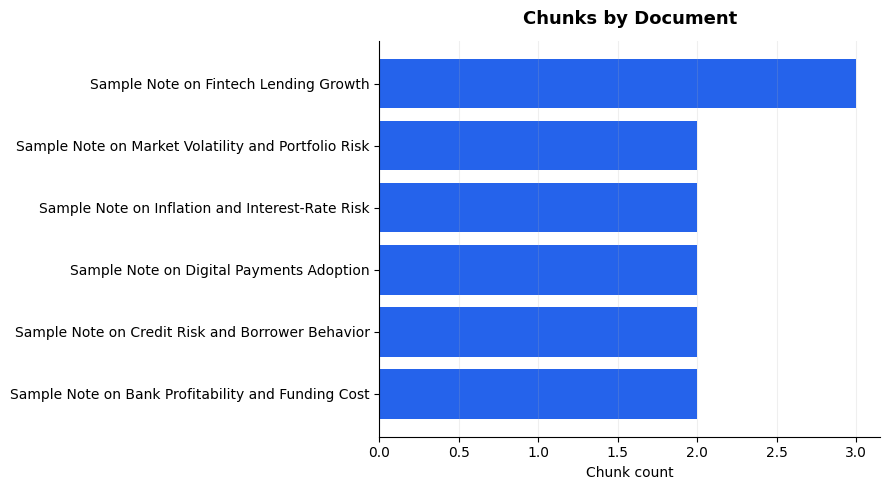

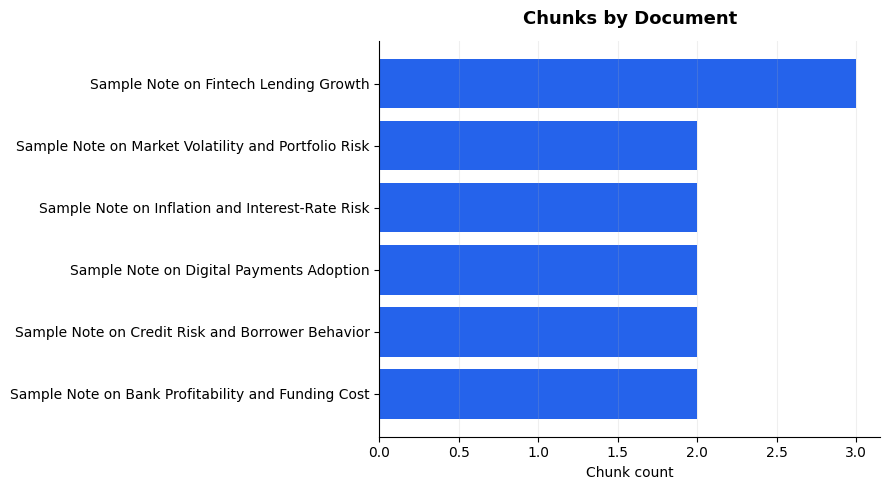

In [9]:
fig = plot_chunks_by_document(chunks)
fig.savefig(FIGURES_DIR / "chunks_by_document.png", dpi=150, bbox_inches="tight")
fig

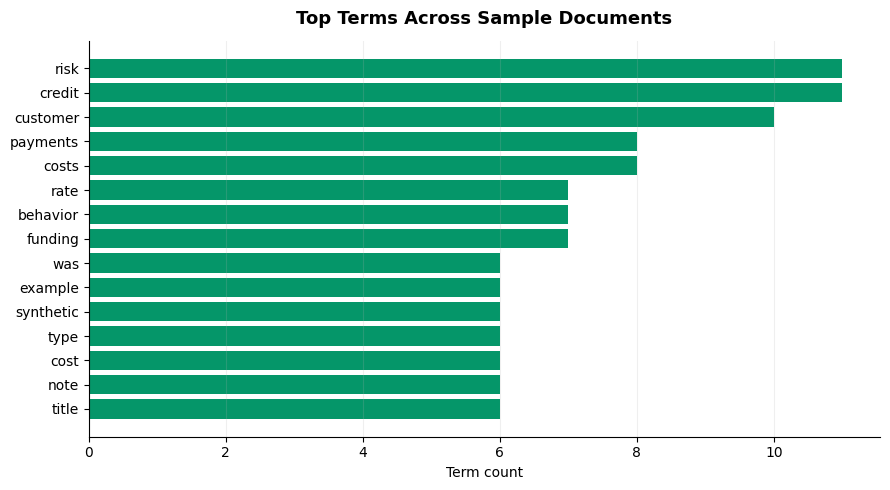

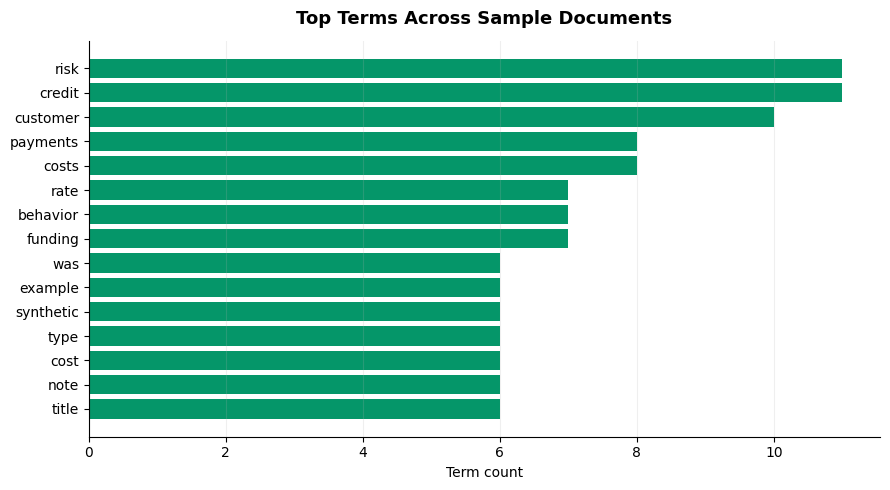

In [10]:
fig = plot_top_terms_overall(chunks)
fig.savefig(FIGURES_DIR / "top_terms_overall.png", dpi=150, bbox_inches="tight")
fig

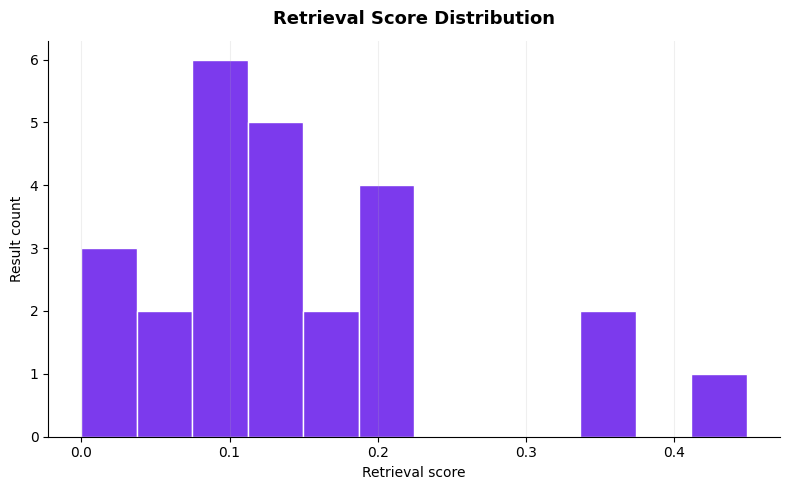

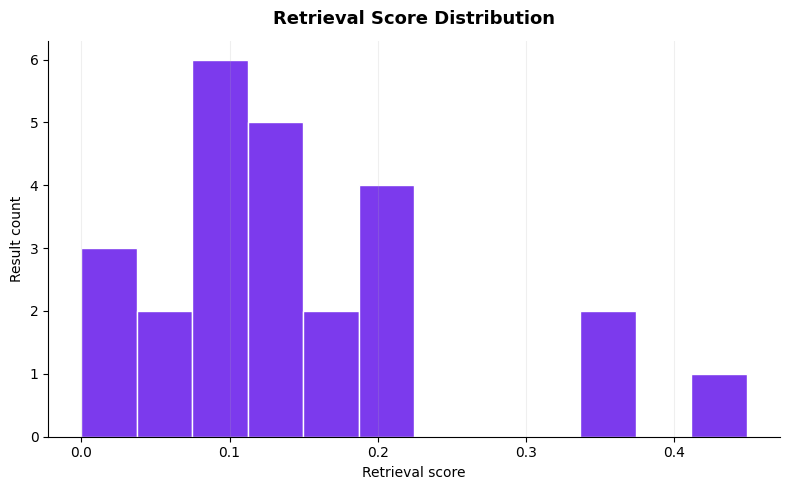

In [11]:
fig = plot_retrieval_score_distribution(retrieval_results)
fig.savefig(FIGURES_DIR / "retrieval_score_distribution.png", dpi=150, bbox_inches="tight")
fig

## Initial interpretation

The retrieval pipeline can connect finance questions to source chunks without using a paid API. This creates a traceable evidence layer for later memo generation. The highest ranked chunks generally align with the query themes: credit risk queries retrieve borrower behavior and fintech lending notes; inflation queries retrieve rate and funding cost notes; digital payments queries retrieve the payments adoption note.

## Limitations

- Sample documents are synthetic and short.
- TF-IDF is lexical and does not understand meaning like an embedding model.
- No LLM generation or final research memo is built in Phase 0.
- No PDF parser, table parser, or production document ingestion layer yet.

## Next steps for Phase 1

- Add memo drafting from retrieved evidence.
- Add risk flag extraction.
- Add citation grounding and evaluation checks.
- Compare retrieval coverage across questions.